In [50]:
!git clone https://github.com/JBiiiS/forecasting_vol.git


Cloning into 'forecasting_vol'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 47 (delta 17), reused 46 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 23.69 KiB | 2.96 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [51]:
import os
os.chdir('forecasting_vol')

In [52]:
!git pull origin main

From https://github.com/JBiiiS/forecasting_vol
 * branch            main       -> FETCH_HEAD
Already up to date.


In [ ]:
pip install -U  finance-datareader

In [ ]:
pip install torchdiffeq

In [ ]:
pip install torchcde

In [ ]:
'''
!pip uninstall -y sympy
!pip install sympy==1.12
'''

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import FinanceDataReader as fdr
import random
import seaborn as sns
import torchdiffeq
import torchcde

from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader

from base.base_config import BaseConfig
from base.data_process import *
from base.time_covariate_encoder import TimeCovariateEncoder

from dlqf_rnn.dlqf_rnn_config import DLQFRNNConfig
from dlqf_rnn.dlqf_rnn_main import *
from dlqf_rnn.dlqf_rnn_main import DLQFRNN

from dlqf_rnn.dlqf_rnn_with_ode_config import DLQFRNNWithODEConfig
from dlqf_rnn.dlqf_rnn_with_ode_model import ODEGenerator
from dlqf_rnn.dlqf_rnn_with_ode_main import DLQFRNNWithODE, DLQFRNNWithODEDiscriminator
from dlqf_rnn.dlqf_rnn_with_ode_main import _train_with_cde
from dlqf_rnn.dlqf_rnn_with_ode_discriminator import CDEDiscriminator

In [54]:
config = DLQFRNNWithODEConfig(input_dim = 6, input_len = 66, learning_rate=0.01) # This config overrides org DLQFRNNCONFIG
config_dict = config.to_dict()
config_dict

device = config.device

In [55]:
# separating config
config_ode = config
config_ode_qlike = config
config_ode_dis = config

# Gathering Data of Y

In [56]:
#S&P 500 08 - 21 Data

df = pd.read_csv('/content/1_min_SPY_2008-2021.csv')
df

,date,open,high,low,close,volume,barCount,average
0,20080122 07:30:00,126.45,126.82,126.00,126.67,30987,4541,126.283
1,20080122 07:31:00,126.67,127.17,126.39,127.12,20111,3125,126.958
2,20080122 07:32:00,127.10,127.13,126.71,126.78,11979,2074,126.922
3,20080122 07:33:00,126.76,126.90,126.53,126.54,8017,1350,126.675
4,20080122 07:34:00,126.54,127.18,126.54,126.78,11967,1253,126.730
...,...,...,...,...,...,...,...,...
1048570,20210506 13:55:00,418.56,418.77,418.48,418.49,9073,4584,418.660
1048571,20210506 13:56:00,418.50,418.73,418.47,418.64,6680,3095,418.622
1048572,20210506 13:57:00,418.64,418.79,418.63,418.79,6912,2868,418.744
1048573,20210506 13:58:00,418.79,418.83,418.71,418.76,7891,3862,418.784


In [57]:
import pandas as pd
import numpy as np
import torch

# ─────────────────────────────────────────
# 1. Parse datetime index
# ─────────────────────────────────────────
df.index = pd.to_datetime(df['date'], format='%Y%m%d %H:%M:%S')

# ─────────────────────────────────────────
# 2. Resample 1-min → 5-min bars
# ─────────────────────────────────────────
df_5m = df.resample('5min').agg({
    'open': 'first', 'high': 'max',
    'low': 'min', 'close': 'last', 'volume': 'sum'
})
df_5m = df_5m[df_5m['close'].notna()]
df_5m = df_5m.between_time('07:30', '13:55')  # MT: equivalent to ET 09:30~15:55

# ─────────────────────────────────────────
# 3. Filter valid days (exactly 78 bars)
# ─────────────────────────────────────────
count_per_day = df_5m.groupby(df_5m.index.date)['close'].count()
valid_days = set(count_per_day[count_per_day == config.total_quantile].index)

df_5m = df_5m[[d in valid_days for d in df_5m.index.date]]

print(f"Valid days : {len(valid_days)}")
print(f"Period     : {min(valid_days)} ~ {max(valid_days)}")

# ─────────────────────────────────────────
# 4. Build Y — 78 log returns per day
#    price sequence: [open_t, close_1, ..., close_78]
#    shape: (N_days, 78)
# ─────────────────────────────────────────
SCALE_FACTOR = config.scale_factor
M = config.total_quantile

Y_list = []
date_list = []

for date, group in df_5m.groupby(df_5m.index.date):
    prices = np.concatenate([
        [group['open'].iloc[0]],
        group['close'].values
    ])

    log_r = np.diff(np.log(prices))  # shape: (total_quantile,)
    abs_r = np.sort(np.abs(log_r)) * SCALE_FACTOR  # ascending sort

    Y_list.append(abs_r)
    date_list.append(pd.Timestamp(date))

Y = torch.tensor(np.array(Y_list), dtype=torch.float32)
date_arr = np.array(date_list)

print(f"\nY shape : {Y.shape}")
print(f"Sample  : {Y[0, :5]}")   # sanity check

Valid days : 1814
Period     : 2008-01-22 ~ 2021-05-06

Y shape : torch.Size([1814, 78])
Sample  : tensor([0.0077, 0.0153, 0.0228, 0.0304, 0.0306])


In [58]:
Y.shape

torch.Size([1814, 78])

In [59]:
Y_np = Y.cpu().numpy()

column = np.arange(1,M+1)
columns = []
for i in column:
  columns.append(str(i)+'/'+str(M))



df_Y = pd.DataFrame(Y_np, index=date_arr, columns=columns)

df_Y

,1/78,2/78,3/78,4/78,5/78,6/78,7/78,8/78,9/78,10/78,...,69/78,70/78,71/78,72/78,73/78,74/78,75/78,76/78,77/78,78/78
2008-01-22,0.007657,0.015289,0.022751,0.030400,0.030621,0.038024,0.038222,0.038374,0.045788,0.061148,...,0.503318,0.526016,0.535497,0.538546,0.558617,0.621430,0.669509,0.681170,0.683884,0.723373
2008-01-23,0.007767,0.007823,0.015585,0.023307,0.023334,0.037686,0.038683,0.038710,0.039165,0.046978,...,0.501602,0.504248,0.506133,0.531773,0.537636,0.549150,0.564296,0.697027,0.714536,0.809905
2008-01-24,0.000000,0.000000,0.007433,0.007437,0.007454,0.014861,0.014865,0.022387,0.029597,0.029696,...,0.333816,0.335708,0.365495,0.388379,0.392811,0.392870,0.431388,0.446762,0.452238,0.640694
2008-01-25,0.000000,0.007409,0.007414,0.007452,0.007469,0.007513,0.014743,0.022231,0.022324,0.022459,...,0.258885,0.262674,0.296209,0.301793,0.312989,0.315032,0.326386,0.401070,0.480255,0.630207
2008-01-30,0.000000,0.000000,0.000000,0.007288,0.007358,0.007358,0.007370,0.014476,0.014731,0.014734,...,0.253798,0.275442,0.291928,0.298801,0.307445,0.314523,0.374601,0.456353,0.525319,0.565700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-30,0.000000,0.002394,0.004786,0.004788,0.004791,0.004793,0.004794,0.007173,0.007181,0.007181,...,0.093307,0.098323,0.107866,0.110317,0.115138,0.119551,0.122289,0.122318,0.127112,0.157929
2021-05-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.002386,0.002388,0.002388,0.002389,0.002390,...,0.081217,0.083605,0.083605,0.085853,0.088315,0.095399,0.097856,0.097858,0.097954,0.107538
2021-05-04,0.002416,0.002416,0.004842,0.004851,0.007247,0.007253,0.009676,0.009678,0.012113,0.014492,...,0.118856,0.126097,0.132942,0.137683,0.178761,0.184225,0.195655,0.233524,0.264997,0.295464
2021-05-05,0.000000,0.002395,0.002398,0.002398,0.002405,0.004790,0.004797,0.004800,0.004807,0.004811,...,0.083992,0.084027,0.086661,0.091164,0.093529,0.110386,0.119867,0.120294,0.141989,0.252371


# Gathering Data of X

Because I couldn't access to the high-frequency data of QQQ & DIA, I only exploited SPY data.

In [60]:
spy = fdr.DataReader('SPY', start='2007-06-20', end = '2021-05-07')

In [61]:
# spy_close_price
spy_close_and_volume = clean_price_data(spy[['Close','Volume']], no_minus=True)
_, ln_spy = log_data(spy_close_and_volume)
ln_spy = clean_price_data(ln_spy)
ln_spy.head()

The number of <= 0 data : Close     0
Volume    0
dtype: int64


/content/forecasting_vol/base/data_process.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s[s <= 0] = np.nan
/content/forecasting_vol/base/data_process.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s[s <= 0] = np.nan


,Close,Volume
2007-06-20,0.005542,0.147461
2007-06-21,0.005542,0.147461
2007-06-22,-0.009454,-0.001449
2007-06-25,-0.004794,0.123962
2007-06-26,-0.010332,-0.156284


In [62]:
# calculating daily rv
rv_daily = df_5m.groupby(df_5m.index.date)['close'].apply(
    lambda x: np.sum(np.diff(np.log(x.values))**2)
)
rv_daily.index = pd.to_datetime(rv_daily.index)
rv_daily.name = 'RV'


df_X = pd.DataFrame({
    'R' : ln_spy['Close'],
    'RV': rv_daily,
    'Volume': ln_spy['Volume']
}).dropna()
df_X

,R,RV,Volume
2008-01-22,-0.010199,0.000694,0.223653
2008-01-23,0.023737,0.000738,0.160687
2008-01-24,0.008406,0.000316,-0.677668
2008-01-25,-0.014551,0.000244,0.036467
2008-01-30,-0.007385,0.000206,0.684238
...,...,...,...
2021-04-30,-0.006592,0.000026,0.085169
2021-05-03,0.002154,0.000015,-0.227439
2021-05-04,-0.006188,0.000063,0.399564
2021-05-05,0.000313,0.000022,-0.523913


In [63]:
df_X = df_X[:-1]
df_Y = df_Y[config.input_len:]

In [64]:
df_X

,R,RV,Volume
2008-01-22,-0.010199,0.000694,0.223653
2008-01-23,0.023737,0.000738,0.160687
2008-01-24,0.008406,0.000316,-0.677668
2008-01-25,-0.014551,0.000244,0.036467
2008-01-30,-0.007385,0.000206,0.684238
...,...,...,...
2021-04-29,0.006353,0.000027,0.427164
2021-04-30,-0.006592,0.000026,0.085169
2021-05-03,0.002154,0.000015,-0.227439
2021-05-04,-0.006188,0.000063,0.399564


In [65]:
df_Y

,1/78,2/78,3/78,4/78,5/78,6/78,7/78,8/78,9/78,10/78,...,69/78,70/78,71/78,72/78,73/78,74/78,75/78,76/78,77/78,78/78
2008-08-04,0.000000,0.000000,0.007949,0.007979,0.007982,0.007995,0.008000,0.015882,0.015950,0.015959,...,0.135442,0.135474,0.143415,0.159160,0.159515,0.175551,0.215028,0.278076,0.303563,0.327751
2008-08-05,0.000000,0.000000,0.000000,0.007855,0.007858,0.007861,0.007881,0.007892,0.007930,0.015641,...,0.102197,0.109847,0.125108,0.125687,0.133832,0.164932,0.181725,0.218562,0.293035,0.360474
2008-08-06,0.000000,0.000000,0.000000,0.007764,0.007785,0.007785,0.007790,0.007805,0.007823,0.015493,...,0.124301,0.132704,0.148189,0.148467,0.154955,0.163342,0.171714,0.179093,0.186858,0.288961
2008-08-07,0.000000,0.000000,0.000000,0.000000,0.007791,0.007801,0.007802,0.007803,0.007809,0.007817,...,0.148374,0.148467,0.156165,0.156421,0.179568,0.187178,0.197262,0.210502,0.235147,0.433055
2008-08-08,0.000000,0.007723,0.007755,0.007781,0.007781,0.007782,0.015419,0.015423,0.015455,0.015457,...,0.154571,0.155485,0.165283,0.209051,0.209522,0.210043,0.219953,0.280178,0.307486,0.399233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-30,0.000000,0.002394,0.004786,0.004788,0.004791,0.004793,0.004794,0.007173,0.007181,0.007181,...,0.093307,0.098323,0.107866,0.110317,0.115138,0.119551,0.122289,0.122318,0.127112,0.157929
2021-05-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.002386,0.002388,0.002388,0.002389,0.002390,...,0.081217,0.083605,0.083605,0.085853,0.088315,0.095399,0.097856,0.097858,0.097954,0.107538
2021-05-04,0.002416,0.002416,0.004842,0.004851,0.007247,0.007253,0.009676,0.009678,0.012113,0.014492,...,0.118856,0.126097,0.132942,0.137683,0.178761,0.184225,0.195655,0.233524,0.264997,0.295464
2021-05-05,0.000000,0.002395,0.002398,0.002398,0.002405,0.004790,0.004797,0.004800,0.004807,0.004811,...,0.083992,0.084027,0.086661,0.091164,0.093529,0.110386,0.119867,0.120294,0.141989,0.252371


In [66]:
#Setting Parameter

config.batch_size = 32
total_batch = len(df_Y) // config.batch_size
total_batch

54

In [67]:
test_batch_num = 9
train_batch_num = int((total_batch - test_batch_num) * 0.75) + 1
val_batch_num = total_batch - train_batch_num - test_batch_num


In [68]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader



# ─────────────────────────────────────────
# 1. Index-based split constants
# ─────────────────────────────────────────
BATCH_SIZE = config.batch_size
N_USE      = total_batch * BATCH_SIZE

TRAIN_END  = train_batch_num * BATCH_SIZE
VAL_END    = TRAIN_END + val_batch_num * BATCH_SIZE

Y_raw = df_Y.iloc[:N_USE]

# ─────────────────────────────────────────
# 2. Z-score normalization — fit on train window rows only
# ─────────────────────────────────────────
feat_cols = ['R', 'RV', 'Volume']

X_train_rows = df_X.iloc[:TRAIN_END + config.input_len]
means = X_train_rows[feat_cols].mean()
stds  = X_train_rows[feat_cols].std() + 1e-6

X_norm = (df_X[feat_cols] - means) / stds  # normalize entire df_X
X_vals = X_norm.values.astype(np.float32)

# ─────────────────────────────────────────
# 3. Time covariate encoder — fit on train dates only
# ─────────────────────────────────────────
time_embedder = TimeCovariateEncoder()
train_dates   = pd.DatetimeIndex(Y_raw.index[:TRAIN_END])
time_embedder.fit(train_dates)

# ─────────────────────────────────────────
# 4. Build (N, input_len, 6) rolling window tensor
#    each timestep: [R, RV, Volume, weekday, month, quarter]
# ─────────────────────────────────────────
X_dates = df_X.index  # full date index of df_X

all_idx = np.arange(N_USE).tolist()

# (N, input_len, 3) — normalized financial features
windows = np.array([X_vals[i : i + config.input_len] for i in all_idx], dtype=np.float32)

# (N, input_len, 3) — time covariates per timestep in window
date_windows = [pd.DatetimeIndex(X_dates[i : i + config.input_len]) for i in all_idx]
time_windows = np.stack([
    time_embedder.transform(d).numpy() for d in date_windows
], axis=0)

# (N, input_len, 6) — concatenate along feature dim
X_full = np.concatenate([windows, time_windows], axis=2)

X_tensor = torch.tensor(X_full, dtype=torch.float32)
Y_tensor = torch.tensor(Y_raw.values, dtype=torch.float32)

print(f"X_tensor: {X_tensor.shape}")
print(f"Y_tensor: {Y_tensor.shape}")

# ─────────────────────────────────────────
# 5. Train / Val / Test split
# ─────────────────────────────────────────
X_tr,  X_val,  X_te  = X_tensor[:TRAIN_END], X_tensor[TRAIN_END:VAL_END], X_tensor[VAL_END:]
Y_tr,  Y_val,  Y_te  = Y_tensor[:TRAIN_END], Y_tensor[TRAIN_END:VAL_END], Y_tensor[VAL_END:]

print(f"\nTrain : X {X_tr.shape}, Y {Y_tr.shape}")
print(f"Val   : X {X_val.shape}, Y {Y_val.shape}")
print(f"Test  : X {X_te.shape}, Y {Y_te.shape}")

test_list_x = []
test_list_y = []

for i in range(4):
    test_list_x.append(X_te[i*66:(i+1)*66,:,:])
    test_list_y.append(Y_te[i*66:(i+1)*66,:])

X_te = test_list_x
Y_te = test_list_y

# ─────────────────────────────────────────
# 6. Dataset & DataLoader
# ─────────────────────────────────────────
class DLQFDataset(Dataset):
    """
    x : (66, 6)  — [R, RV, Volume, weekday, month, quarter] per timestep
    y : (78,)    — sorted |log return| × 100
    """
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


train_loader = DataLoader(DLQFDataset(X_tr,  Y_tr),  batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(DLQFDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")

# ─────────────────────────────────────────
# 7. Sanity check
# ─────────────────────────────────────────
x_b, y_b = next(iter(train_loader))
print(f"\nSanity check:")
print(f"  x : {x_b.shape}")
print(f"  y : {y_b.shape}")
print(f"Seperating Test Set, so that each tensor doesn't share any identical data with each other.\nTest Set Number: {len(X_te)} | Test Tensor Shape: {X_te[1].shape}")

X_tensor: torch.Size([1728, 66, 6])
Y_tensor: torch.Size([1728, 78])

Train : X torch.Size([1088, 66, 6]), Y torch.Size([1088, 78])
Val   : X torch.Size([352, 66, 6]), Y torch.Size([352, 78])
Test  : X torch.Size([288, 66, 6]), Y torch.Size([288, 78])

Train batches : 34
Val   batches : 11

Sanity check:
  x : torch.Size([32, 66, 6])
  y : torch.Size([32, 78])
Seperating Test Set, so that each tensor doesn't share any identical data with each other.
Test Set Number: 4 | Test Tensor Shape: torch.Size([66, 66, 6])


In [69]:
X_te[1]

tensor([[[-6.8034e-02, -3.0056e-01, -6.1129e-01, -7.9195e-01, -1.3341e+00,
          -1.3699e+00],
         [-4.7868e-02, -3.1019e-01,  1.9866e-03, -9.4265e-02, -1.3341e+00,
          -1.3699e+00],
         [-1.5873e-01, -2.2356e-01, -3.1800e-01,  1.3011e+00, -1.0454e+00,
          -1.3699e+00],
         ...,
         [ 4.7716e-01, -2.6505e-01, -3.4862e-01, -9.4265e-02,  3.9799e-01,
           4.1082e-01],
         [ 8.7729e-01, -2.9277e-01, -9.8131e-02,  6.0342e-01,  3.9799e-01,
           4.1082e-01],
         [-4.8901e-02, -2.7362e-01,  2.5750e-01,  1.3011e+00,  3.9799e-01,
           4.1082e-01]],

        [[-4.7868e-02, -3.1019e-01,  1.9866e-03, -9.4265e-02, -1.3341e+00,
          -1.3699e+00],
         [-1.5873e-01, -2.2356e-01, -3.1800e-01,  1.3011e+00, -1.0454e+00,
          -1.3699e+00],
         [ 2.3761e-01, -3.3296e-01, -8.4226e-01, -1.4896e+00, -1.0454e+00,
          -1.3699e+00],
         ...,
         [ 8.7729e-01, -2.9277e-01, -9.8131e-02,  6.0342e-01,  3.9799e-01,
    

In [70]:
Y_te[1].shape

torch.Size([66, 78])

# Overwrite saved states

## DLQF RNN

In [71]:
# Plz check the config is equal to one which was allocated when the state was downloaded.


M = config.total_quantile
alpha = torch.linspace(1 / M, 1, M).to(device)

config.num_epochs = 50
device = config.device
config.hidden_dim = 11
config.latent_dim_1 =10
config.latent_dim_2 = 11
config.latent_dim_3 = 3
cfg = config



model = DLQFRNN(cfg).to(device)

checkpoint_path = '/content/best_state.pt'

state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)

model.load_state_dict(state_dict)

model.eval()

print("Original Model weights successfully loaded and set to evaluation mode.")

Original Model weights successfully loaded and set to evaluation mode.


## DLQF RNN WITH ODE

In [72]:
# Plz check the config is equal to one which was allocated when the state was downloaded.

config_ode.hidden_dim = 11
config_ode.lstm_hidden_dim = 11
config_ode.ode_hidden_dim = 11
config_ode.use_learnable_exp = False
config_ode.use_non_learnable_exp = True
config_ode.exp_deno_init = 6

cfg = config_ode


model_ode = DLQFRNNWithODE(cfg).to(device)

checkpoint_path = '/content/best_state_ode.pt'

state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)

model_ode.load_state_dict(state_dict)

model_ode.eval()

print("ODE Model weights successfully loaded and set to evaluation mode.")

ODE Model weights successfully loaded and set to evaluation mode.


## ODE-QF with QLIKE

In [73]:
# Plz check the config is equal to one which was allocated when the state was downloaded.

config_ode_qlike.hidden_dim = 7
config_ode_qlike.lstm_hidden_dim = 7
config_ode_qlike.ode_hidden_dim = 10
config_ode_qlike.use_learnable_exp = False
config_ode_qlike.use_non_learnable_exp = True
config_ode_qlike.exp_deno_init = 20


cfg = config_ode_qlike


model_ode_qlike = DLQFRNNWithODE(cfg).to(device)

checkpoint_path = '/content/best_state_ode_qlike_0.05.pt'

state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)

model_ode_qlike.load_state_dict(state_dict)

model_ode_qlike.eval()

print("ODE QLIKE Model weights successfully loaded and set to evaluation mode.")

ODE QLIKE Model weights successfully loaded and set to evaluation mode.


## ODE-QF on GAN (Before Training)

In [39]:
# Plz check the config is equal to one which was allocated when the state was downloaded.

config_ode_dis.hidden_dim = 7
config_ode_dis.lstm_hidden_dim =7
config_ode_dis.ode_hidden_dim = 10
config_ode_dis.use_learnable_exp = False
config_ode_dis.use_non_learnable_exp = True
config_ode_dis.exp_deno_init = 20
config_ode_dis.lambda_gan = 1.0
config_ode_dis.lambda_l2 = 1.0
config_ode_dis.l2_coef = 1.0
config_ode_dis.only_d_epoch = 19
cfg=config_ode_dis





model_ode_with_dis = DLQFRNNWithODE(cfg).to(device)

checkpoint_path = '/content/best_state_ode_qlike_0.05.pt'

state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)

model_ode_with_dis.load_state_dict(state_dict)

model_ode_with_dis.eval()

print("ODE-DIS Before GAN Training Model weights successfully loaded and set to evaluation mode.")

ODE-DIS Before GAN Training Model weights successfully loaded and set to evaluation mode.


## ODE-QF on GAN (After Training)

In [74]:
# Plz check the config is equal to one which was allocated when the state was downloaded.


config_ode_dis.hidden_dim = 7
config_ode_dis.lstm_hidden_dim =7
config_ode_dis.ode_hidden_dim = 10
config_ode_dis.use_learnable_exp = False
config_ode_dis.use_non_learnable_exp = True
config_ode_dis.exp_deno_init = 20
config_ode_dis.lambda_gan = 1.0
config_ode_dis.lambda_l2 = 1.0
config_ode_dis.lambda_qlike = 0.0
config_ode_dis.l2_coef = 1.0
config_ode_dis.qlike_coef = 0.0
config_ode_dis.only_d_epoch = 19
cfg=config_ode_dis




model_ode_with_dis = DLQFRNNWithODE(cfg).to(device)

checkpoint_path = '/content/best_state_ode_with_dis.pt'

state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)

model_ode_with_dis.load_state_dict(state_dict)

model_ode_with_dis.eval()

print("ODE-DIS After GAN Training Model weights successfully loaded and set to evaluation mode.")

ODE-DIS After GAN Training Model weights successfully loaded and set to evaluation mode.


# Tuning

In [ ]:
pip install optuna

## DLQF RNN

In [ ]:
import optuna

def objective(trial):
    hidden_dim = trial.suggest_int('hidden_dim', 5, 16)
    latent_dim_1 = trial.suggest_int('latent_dim_1', 5, 16)
    latent_dim_2 = trial.suggest_int('latent_dim_2', 4, 16)
    latent_dim_3 = trial.suggest_int('latent_dim_3', 2, 8)


    cfg = config
    cfg.hidden_dim = hidden_dim
    cfg.latent_dim_1 = latent_dim_1
    cfg.latent_dim_2 = latent_dim_2
    cfg.latent_dim_3 = latent_dim_3

    lr= 0.01


    M = cfg.total_quantile
    alpha = torch.linspace(1 / M, 1, M).to(device)

    torch.manual_seed(42)
    model = DLQFRNN(cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float('inf')
    no_improve = 0

    for epoch in range(50):
        model.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            r_q, gamma = model(x_b, alpha)
            loss_l2 = l2_distance_loss(y_b, r_q)

            rv_pred_unscaled = (r_q.detach() ** 2).sum(dim=1) + gamma
            rv_true_unscaled = (y_b ** 2).sum(dim=1)
            rv_pred = rv_pred_unscaled / (cfg.scale_factor ** 2)
            rv_true = rv_true_unscaled / (cfg.scale_factor ** 2)
            loss_qlike = qlike_loss(rv_true, rv_pred)


            total_loss = loss_l2 + loss_qlike
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                r_q, gamma = model(x_b, alpha)
                loss_l2 = l2_distance_loss(y_b, r_q)

                rv_pred_unscaled = (r_q ** 2).sum(dim=1) + gamma
                rv_true_unscaled = (y_b ** 2).sum(dim=1)
                rv_pred = rv_pred_unscaled / (cfg.scale_factor ** 2)
                rv_true = rv_true_unscaled / (cfg.scale_factor ** 2)
                loss_qlike = qlike_loss(rv_true, rv_pred)

                total_loss = loss_l2 + loss_qlike
                val_loss += total_loss.item()
        val_loss /= len(val_loader)

        if val_loss < best_val:
            best_val = val_loss

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=15)
)
study.optimize(objective, n_trials=50)

print("\n" + "="*45)
print("Best Parameters:")
print("="*45)
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"  Best Val Loss: {study.best_value:.6f}")



[I 2026-03-15 07:49:58,134] A new study created in memory with name: no-name-13505f91-93fa-4a42-af5b-dcd3e42ab800
[I 2026-03-15 07:50:13,605] Trial 0 finished with value: 0.3958936740051616 and parameters: {'hidden_dim': 14, 'latent_dim_1': 16, 'latent_dim_2': 16, 'latent_dim_3': 7}. Best is trial 0 with value: 0.3958936740051616.
[I 2026-03-15 07:50:25,450] Trial 1 finished with value: 0.4670552773909135 and parameters: {'hidden_dim': 13, 'latent_dim_1': 5, 'latent_dim_2': 8, 'latent_dim_3': 8}. Best is trial 0 with value: 0.3958936740051616.
[I 2026-03-15 07:50:37,333] Trial 2 finished with value: 0.30728557164018805 and parameters: {'hidden_dim': 14, 'latent_dim_1': 8, 'latent_dim_2': 16, 'latent_dim_3': 2}. Best is trial 2 with value: 0.30728557164018805.
[I 2026-03-15 07:50:49,185] Trial 3 finished with value: 0.33237598023631354 and parameters: {'hidden_dim': 7, 'latent_dim_1': 10, 'latent_dim_2': 15, 'latent_dim_3': 5}. Best is trial 2 with value: 0.30728557164018805.
[I 2026-03


Best Parameters:
  hidden_dim: 11
  latent_dim_1: 10
  latent_dim_2: 11
  latent_dim_3: 3
  Best Val Loss: 0.299934


## DLQF RNN ODE

In [ ]:
import optuna

def objective(trial):
    hidden_dim = trial.suggest_int('hidden_dim', 5, 16)
    ode_hidden_dim = trial.suggest_int('ode_hidden_dim', 5, 20)
    exp_deno_init = trial.suggest_int('exp_deno_init', 1, 20)

    cfg = config

    cfg.hidden_dim = hidden_dim
    cfg.lstm_hidden_dim = hidden_dim

    cfg.ode_hidden_dim = ode_hidden_dim
    cfg.exp_deno_init = exp_deno_init


    lr = 0.01
    cfg.use_learnable_exp = False
    cfg.use_non_learnable_exp = True
    cfg.ode_times = torch.linspace(0, 1, cfg.total_quantile).to(device)

    torch.manual_seed(42)
    model = DLQFRNNWithODE(cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float('inf')
    no_improve = 0
    PATIENCE = 5
    MIN_EPOCHS = 10
    FULL_EPOCHS = 50

    for epoch in range(FULL_EPOCHS):
        model.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)

            r_q_ode = model(x_b)
            loss_l2 = l2_distance_loss(y_b, r_q_ode)

            total_loss = loss_l2

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                r_q_ode = model(x_b)
                loss_l2 = l2_distance_loss(y_b, r_q_ode)

                total_loss = loss_l2
                val_loss += total_loss.item()

        val_loss /= len(val_loader)

        if val_loss < best_val:
            best_val = val_loss
            no_improve = 0
        else:
            no_improve += 1

        if epoch >= MIN_EPOCHS and no_improve >= PATIENCE:
            break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=15)
)
study.optimize(objective, n_trials=50)

print("\n" + "="*45)
print("Best Parameters:")
print("="*45)
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"  Best Val Loss: {study.best_value:.6f}")

[I 2026-03-15 05:08:29,232] A new study created in memory with name: no-name-c2feb4dd-eeca-4662-b880-2068f8a7f7f2
[I 2026-03-15 05:10:21,456] Trial 0 finished with value: 0.03600226749073376 and parameters: {'hidden_dim': 9, 'ode_hidden_dim': 8, 'exp_deno_init': 5}. Best is trial 0 with value: 0.03600226749073376.
[I 2026-03-15 05:12:05,835] Trial 1 finished with value: 0.03775064257735556 and parameters: {'hidden_dim': 13, 'ode_hidden_dim': 19, 'exp_deno_init': 5}. Best is trial 0 with value: 0.03600226749073376.
[I 2026-03-15 05:15:56,095] Trial 2 finished with value: 0.03793813152746721 and parameters: {'hidden_dim': 5, 'ode_hidden_dim': 19, 'exp_deno_init': 1}. Best is trial 0 with value: 0.03600226749073376.
[I 2026-03-15 05:17:56,834] Trial 3 finished with value: 0.039378257637674156 and parameters: {'hidden_dim': 14, 'ode_hidden_dim': 5, 'exp_deno_init': 1}. Best is trial 0 with value: 0.03600226749073376.
[I 2026-03-15 05:20:08,137] Trial 4 finished with value: 0.03827299279245


Best Parameters:
  hidden_dim: 11
  ode_hidden_dim: 11
  exp_deno_init: 6
  Best Val Loss: 0.035599


## ODE-QF with QLIKE

In [ ]:
import optuna
# qlike = 0.05

def objective(trial):
    hidden_dim = trial.suggest_int('hidden_dim', 5, 16)
    ode_hidden_dim = trial.suggest_int('ode_hidden_dim', 5, 20)
    exp_deno_init = trial.suggest_int('exp_deno_init', 1, 20)

    cfg = config_ode_qlike

    cfg.hidden_dim = hidden_dim
    cfg.lstm_hidden_dim = hidden_dim

    cfg.ode_hidden_dim = ode_hidden_dim
    cfg.exp_deno_init = exp_deno_init

    lambda_qlike = 0.05

    lr = 0.01
    cfg.use_learnable_exp = False
    cfg.use_non_learnable_exp = True
    cfg.ode_times = torch.linspace(0, 1, cfg.total_quantile).to(device)

    torch.manual_seed(42)
    model = DLQFRNNWithODE(cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float('inf')
    no_improve = 0
    PATIENCE = 5
    MIN_EPOCHS = 10
    FULL_EPOCHS = 50

    for epoch in range(FULL_EPOCHS):
        model.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)

            r_q_ode = model(x_b)
            loss_l2 = l2_distance_loss(y_b, r_q_ode)

            rv_pred = (r_q_ode ** 2).sum(dim=1) / (cfg.scale_factor ** 2)
            rv_true = (y_b ** 2).sum(dim=1) / (cfg.scale_factor ** 2)

            qlike = qlike_loss(rv_true, rv_pred)

            total_loss = loss_l2 + lambda_qlike * qlike

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)

                r_q_ode = model(x_b)
                loss_l2 = l2_distance_loss(y_b, r_q_ode)

                rv_pred = (r_q_ode ** 2).sum(dim=1) / (cfg.scale_factor ** 2)
                rv_true = (y_b ** 2).sum(dim=1) / (cfg.scale_factor ** 2)

                total_loss = loss_l2
                val_loss += total_loss.item()

        val_loss /= len(val_loader)

        if val_loss < best_val:
            best_val = val_loss
            no_improve = 0
        else:
            no_improve += 1

        if epoch >= MIN_EPOCHS and no_improve >= PATIENCE:
            break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=15)
)
study.optimize(objective, n_trials=50)

print("\n" + "="*45)
print("Best Parameters:")
print("="*45)
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"  Best Val Loss: {study.best_value:.6f}")

[I 2026-03-15 14:30:05,204] A new study created in memory with name: no-name-f4fc1371-51ca-4fb4-a329-4bbc62bf5978
[I 2026-03-15 14:31:22,771] Trial 0 finished with value: 0.04284789311614903 and parameters: {'hidden_dim': 10, 'ode_hidden_dim': 14, 'exp_deno_init': 7}. Best is trial 0 with value: 0.04284789311614903.
[I 2026-03-15 14:32:49,399] Trial 1 finished with value: 0.03970099731602452 and parameters: {'hidden_dim': 14, 'ode_hidden_dim': 17, 'exp_deno_init': 2}. Best is trial 1 with value: 0.03970099731602452.
[I 2026-03-15 14:34:20,829] Trial 2 finished with value: 0.041839969090440056 and parameters: {'hidden_dim': 9, 'ode_hidden_dim': 5, 'exp_deno_init': 16}. Best is trial 1 with value: 0.03970099731602452.
[I 2026-03-15 14:36:22,464] Trial 3 finished with value: 0.03889418444172903 and parameters: {'hidden_dim': 10, 'ode_hidden_dim': 19, 'exp_deno_init': 6}. Best is trial 3 with value: 0.03889418444172903.
[I 2026-03-15 14:38:00,782] Trial 4 finished with value: 0.04159445688


Best Parameters:
  hidden_dim: 7
  ode_hidden_dim: 10
  exp_deno_init: 20
  Best Val Loss: 0.036677


In [ ]:
# qlike = 0.1

def objective(trial):
    hidden_dim = trial.suggest_int('hidden_dim', 5, 16)
    ode_hidden_dim = trial.suggest_int('ode_hidden_dim', 5, 20)
    exp_deno_init = trial.suggest_int('exp_deno_init', 1, 20)

    cfg = config_ode_qlike

    cfg.hidden_dim = hidden_dim
    cfg.lstm_hidden_dim = hidden_dim

    cfg.ode_hidden_dim = ode_hidden_dim
    cfg.exp_deno_init = exp_deno_init

    lambda_qlike = 0.1

    lr = 0.01
    cfg.use_learnable_exp = False
    cfg.use_non_learnable_exp = True
    cfg.ode_times = torch.linspace(0, 1, cfg.total_quantile).to(device)

    torch.manual_seed(42)
    model = DLQFRNNWithODE(cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float('inf')
    no_improve = 0
    PATIENCE = 5
    MIN_EPOCHS = 10
    FULL_EPOCHS = 50

    for epoch in range(FULL_EPOCHS):
        model.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)

            r_q_ode = model(x_b)
            loss_l2 = l2_distance_loss(y_b, r_q_ode)

            rv_pred = (r_q_ode ** 2).sum(dim=1) / (cfg.scale_factor ** 2)
            rv_true = (y_b ** 2).sum(dim=1) / (cfg.scale_factor ** 2)

            qlike = qlike_loss(rv_true, rv_pred)

            total_loss = loss_l2 + lambda_qlike * qlike

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)

                r_q_ode = model(x_b)
                loss_l2 = l2_distance_loss(y_b, r_q_ode)

                rv_pred = (r_q_ode ** 2).sum(dim=1) / (cfg.scale_factor ** 2)
                rv_true = (y_b ** 2).sum(dim=1) / (cfg.scale_factor ** 2)

                total_loss = loss_l2
                val_loss += total_loss.item()

        val_loss /= len(val_loader)

        if val_loss < best_val:
            best_val = val_loss
            no_improve = 0
        else:
            no_improve += 1

        if epoch >= MIN_EPOCHS and no_improve >= PATIENCE:
            break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=15)
)
study.optimize(objective, n_trials=50)

print("\n" + "="*45)
print("Best Parameters:")
print("="*45)
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"  Best Val Loss: {study.best_value:.6f}")

[I 2026-03-15 09:37:52,834] A new study created in memory with name: no-name-49cc6ac1-b2c7-41e3-9f43-6a6960b4bbb7
[I 2026-03-15 09:39:40,631] Trial 0 finished with value: 0.04138952595266429 and parameters: {'hidden_dim': 13, 'ode_hidden_dim': 9, 'exp_deno_init': 3}. Best is trial 0 with value: 0.04138952595266429.
[I 2026-03-15 09:41:24,117] Trial 1 finished with value: 0.04245517538352446 and parameters: {'hidden_dim': 11, 'ode_hidden_dim': 7, 'exp_deno_init': 17}. Best is trial 0 with value: 0.04138952595266429.
[I 2026-03-15 09:43:58,981] Trial 2 finished with value: 0.04068712060424415 and parameters: {'hidden_dim': 13, 'ode_hidden_dim': 15, 'exp_deno_init': 14}. Best is trial 2 with value: 0.04068712060424415.
[I 2026-03-15 09:45:42,183] Trial 3 finished with value: 0.0420710485089909 and parameters: {'hidden_dim': 11, 'ode_hidden_dim': 15, 'exp_deno_init': 16}. Best is trial 2 with value: 0.04068712060424415.
[I 2026-03-15 09:47:31,782] Trial 4 finished with value: 0.04453648220


Best Parameters:
  hidden_dim: 5
  ode_hidden_dim: 16
  exp_deno_init: 9
  Best Val Loss: 0.037625


# Training

## DLQF RNN

In [ ]:
# ─────────────────────────────────────────
# Config 업데이트
# ─────────────────────────────────────────

M = config.total_quantile
alpha = torch.linspace(1 / M, 1, M).to(device)

config.num_epochs = 50
device = config.device
config.hidden_dim = 11
config.latent_dim_1 =10
config.latent_dim_2 = 11
config.latent_dim_3 = 3
cfg = config

# ─────────────────────────────────────────
# Model
# ─────────────────────────────────────────
torch.manual_seed(cfg.seed)
model = DLQFRNN(cfg).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
M = cfg.total_quantile
alpha = torch.linspace(1 / M, 1, M).to(device)

# ─────────────────────────────────────────
# Training loop (Early Stopping 없음)
# ─────────────────────────────────────────
best_val_loss = float('inf')
best_state    = None

for epoch in range(cfg.num_epochs):

    # ── Train ──────────────────────────────
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        x_b, y_b = batch
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        r_q, gamma  = model(x_b, alpha)
        loss_l2 = l2_distance_loss(y_b, r_q)

        rv_pred_unscaled = (r_q.detach() ** 2).sum(dim=1) + gamma
        rv_true_unscaled = (y_b ** 2).sum(dim=1)

        rv_pred = rv_pred_unscaled / (cfg.scale_factor ** 2)
        rv_true = rv_true_unscaled / (cfg.scale_factor ** 2)

        loss_qlike = qlike_loss(rv_true, rv_pred)

        total_loss = loss_l2 + loss_qlike

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        train_loss += total_loss.item()

    train_loss /= len(train_loader)

    # ── Validation ─────────────────────────
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x_b, y_b = batch
            x_b = x_b.to(device)
            y_b = y_b.to(device)

            r_q, gamma = model(x_b, alpha)
            loss_l2 = l2_distance_loss(y_b, r_q)

            rv_pred_unscaled = (r_q ** 2).sum(dim=1) + gamma
            rv_true_unscaled = (y_b ** 2).sum(dim=1)

            rv_pred = rv_pred_unscaled / (cfg.scale_factor ** 2)
            rv_true = rv_true_unscaled / (cfg.scale_factor ** 2)

            loss_qlike = qlike_loss(rv_true, rv_pred)

            total_loss = loss_l2 + loss_qlike

            val_loss += total_loss.item()

    val_loss /= len(val_loader)

    # ── Checkpoint (최고 성능 저장) ─────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:3d}/{cfg.num_epochs}] "
              f"| Train {train_loss:.6f} "
              f"| Val {val_loss:.6f} "
              f"| Best {best_val_loss:.6f}")

model.load_state_dict(best_state)
model.eval()

Parameters: 5,176
Epoch [  5/50] | Train 0.615221 | Val 0.394465 | Best 0.332870
Epoch [ 10/50] | Train 0.553882 | Val 0.347535 | Best 0.332870
Epoch [ 15/50] | Train 0.309573 | Val 0.317322 | Best 0.317322
Epoch [ 20/50] | Train 0.253341 | Val 0.299934 | Best 0.299934
Epoch [ 25/50] | Train 0.268882 | Val 0.333310 | Best 0.299934
Epoch [ 30/50] | Train 0.249256 | Val 0.309640 | Best 0.299934
Epoch [ 35/50] | Train 0.217453 | Val 0.324980 | Best 0.299934
Epoch [ 40/50] | Train 0.199685 | Val 0.328843 | Best 0.299934
Epoch [ 45/50] | Train 0.193719 | Val 0.335434 | Best 0.299934
Epoch [ 50/50] | Train 0.182436 | Val 0.360425 | Best 0.299934


In [ ]:
torch.save(model.state_dict(), '/content/best_state.pt')

from google.colab import files
files.download('/content/best_state.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## DLQF RNN with ODE

In [ ]:
# ─────────────────────────────────────────
# WO QLIKE LOSS | ONLY L2
# ─────────────────────────────────────────

# ─────────────────────────────────────────
# Config 업데이트
# ─────────────────────────────────────────

config_ode.hidden_dim = 11
config_ode.lstm_hidden_dim = 11
config_ode.ode_hidden_dim = 11
config_ode.use_learnable_exp = False
config_ode.use_non_learnable_exp = True
config_ode.exp_deno_init = 6
cfg = config_ode

# ─────────────────────────────────────────
# Early Stopping Parameters
# ─────────────────────────────────────────
PATIENCE = 5
MIN_EPOCHS = 10
FULL_EPOCHS = 50

# ─────────────────────────────────────────
# Model
# ─────────────────────────────────────────
torch.manual_seed(cfg.seed)
model_ode = DLQFRNNWithODE(cfg).to(device)
optimizer_ode = torch.optim.Adam(
    model_ode.parameters(), lr=cfg.learning_rate)

M = cfg.total_quantile

# ─────────────────────────────────────────
# Training loop
# ─────────────────────────────────────────
best_loss_ode = float('inf')
best_state_ode = None
no_improve = 0

print('ODE-QF RNN Training Started. . .')
for epoch in range(FULL_EPOCHS):

    # ── Train ──────────────────────────────
    model_ode.train()
    train_loss = 0.0

    for batch in train_loader:
        x_b, y_b = batch
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        r_q_ode = model_ode(x_b)
        loss_l2 = l2_distance_loss(y_b, r_q_ode)

        total_loss = loss_l2

        optimizer_ode.zero_grad()
        total_loss.backward()
        optimizer_ode.step()
        train_loss += total_loss.item()

    train_loss /= len(train_loader)

    # ── Validation ─────────────────────────
    model_ode.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x_b, y_b = batch
            x_b = x_b.to(device)
            y_b = y_b.to(device)

            r_q_ode = model_ode(x_b)
            loss_l2 = l2_distance_loss(y_b, r_q_ode)

            total_loss = loss_l2

            val_loss += total_loss.item()

    val_loss /= len(val_loader)

    # ── Checkpoint ─────────────────────────
    if val_loss < best_loss_ode:
        best_loss_ode = val_loss
        best_state_ode = {k: v.clone() for k, v in model_ode.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1:3d}/{FULL_EPOCHS}] "
              f"| Val {val_loss:.6f} "
              f"| Best Val {best_loss_ode:.6f}")

    # ── Early stopping: MIN_EPOCHS 이후 PATIENCE 동안 개선 없으면 종료 ──
    if epoch >= MIN_EPOCHS and no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model_ode.load_state_dict(best_state_ode)
model_ode.eval()
print(f'All train is over. Best Val = {best_loss_ode:.6f}')

ODE-QF RNN Training Started. . .
Epoch [  2/50] | Val 0.150152 | Best Val 0.150106
Epoch [  4/50] | Val 0.148598 | Best Val 0.148598
Epoch [  6/50] | Val 0.044535 | Best Val 0.044535
Epoch [  8/50] | Val 0.040073 | Best Val 0.040073
Epoch [ 10/50] | Val 0.038094 | Best Val 0.038094
Epoch [ 12/50] | Val 0.044198 | Best Val 0.038094
Epoch [ 14/50] | Val 0.044054 | Best Val 0.037786
Epoch [ 16/50] | Val 0.037427 | Best Val 0.037427
Epoch [ 18/50] | Val 0.041100 | Best Val 0.037427
Epoch [ 20/50] | Val 0.035599 | Best Val 0.035599
Epoch [ 22/50] | Val 0.039762 | Best Val 0.035599
Epoch [ 24/50] | Val 0.043184 | Best Val 0.035599

Early stopping at epoch 25
All train is over. Best Val = 0.035599


In [ ]:
torch.save(model_ode.state_dict(), '/content/best_state_ode.pt')

from google.colab import files
files.download('/content/best_state_ode.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ODE-QF with QLIKE

In [35]:
# ─────────────────────────────────────────
# WITH QLIKE LOSS
# ─────────────────────────────────────────

# ─────────────────────────────────────────
# Config 업데이트
# ─────────────────────────────────────────

config_ode_qlike.hidden_dim = 7
config_ode_qlike.lstm_hidden_dim = 7
config_ode_qlike.ode_hidden_dim = 10
config_ode_qlike.use_learnable_exp = False
config_ode_qlike.use_non_learnable_exp = True
config_ode_qlike.exp_deno_init = 20

cfg = config_ode_qlike

lambda_qlike = 0.05

# ─────────────────────────────────────────
# Early Stopping Parameters
# ─────────────────────────────────────────
PATIENCE = 5
MIN_EPOCHS = 10
FULL_EPOCHS = 50

# ─────────────────────────────────────────
# Model
# ─────────────────────────────────────────
torch.manual_seed(cfg.seed)
model_ode_qlike = DLQFRNNWithODE(cfg).to(device)
print(f"Parameters: {sum(p.numel() for p in model_ode_qlike.parameters()):,}")

optimizer_ode_qlike = torch.optim.Adam(
    model_ode_qlike.parameters(), lr=cfg.learning_rate)

M = cfg.total_quantile

cfg.ode_times = torch.linspace(0, 1, cfg.total_quantile).to(device)
# ─────────────────────────────────────────
# Training loop
# ─────────────────────────────────────────
best_loss_ode_qlike = float('inf')
best_state_ode_qlike = None
no_improve = 0

for epoch in range(FULL_EPOCHS):

    # ── Train ──────────────────────────────
    model_ode_qlike.train()
    train_loss = 0.0

    for batch in train_loader:
        x_b, y_b = batch
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        r_q_ode_qlike = model_ode_qlike(x_b)
        loss_l2 = l2_distance_loss(y_b, r_q_ode_qlike)

        rv_pred = (r_q_ode_qlike ** 2).sum(dim=1) / (cfg.scale_factor ** 2)
        rv_true = (y_b ** 2).sum(dim=1) / (cfg.scale_factor ** 2)

        qlike = qlike_loss(rv_true, rv_pred)

        total_loss = loss_l2 + lambda_qlike * qlike

        optimizer_ode_qlike.zero_grad()
        total_loss.backward()
        optimizer_ode_qlike.step()
        train_loss += total_loss.item()

    train_loss /= len(train_loader)

    # ── Validation ─────────────────────────
    model_ode_qlike.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x_b, y_b = batch
            x_b = x_b.to(device)
            y_b = y_b.to(device)

            r_q_ode_qlike = model_ode_qlike(x_b)
            loss_l2 = l2_distance_loss(y_b, r_q_ode_qlike)

            # rv_pred = (r_q_ode_qlike ** 2).sum(dim=1) / (cfg.scale_factor ** 2)
            # rv_true = (y_b ** 2).sum(dim=1) / (cfg.scale_factor ** 2)

            # qlike = qlike_loss(rv_true, rv_pred)

            total_loss = loss_l2
            val_loss += total_loss.item()

    val_loss /= len(val_loader)

    # ── Checkpoint ─────────────────────────
    if val_loss < best_loss_ode_qlike:
        best_loss_ode_qlike = val_loss
        best_state_ode_qlike = {k: v.clone() for k, v in model_ode_qlike.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1:3d}/{FULL_EPOCHS}] "
              f"| Val {val_loss:.6f} "
              f"| Best Val {best_loss_ode_qlike:.6f}")

    # ── Early stopping: MIN_EPOCHS 이후 PATIENCE 동안 개선 없으면 종료 ──
    if epoch >= MIN_EPOCHS and no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model_ode_qlike.load_state_dict(best_state_ode_qlike)
model_ode_qlike.eval()


Parameters: 2,713
Epoch [  2/50] | Val 0.073733 | Best Val 0.073733
Epoch [  4/50] | Val 0.053113 | Best Val 0.050294
Epoch [  6/50] | Val 0.055144 | Best Val 0.047046
Epoch [  8/50] | Val 0.048410 | Best Val 0.047046
Epoch [ 10/50] | Val 0.049706 | Best Val 0.047046
Epoch [ 12/50] | Val 0.049305 | Best Val 0.046768
Epoch [ 14/50] | Val 0.043004 | Best Val 0.040198
Epoch [ 16/50] | Val 0.042860 | Best Val 0.040198
Epoch [ 18/50] | Val 0.052442 | Best Val 0.039961
Epoch [ 20/50] | Val 0.038164 | Best Val 0.038164
Epoch [ 22/50] | Val 0.040815 | Best Val 0.037677
Epoch [ 24/50] | Val 0.044087 | Best Val 0.036677
Epoch [ 26/50] | Val 0.038746 | Best Val 0.036677
Epoch [ 28/50] | Val 0.039145 | Best Val 0.036677

Early stopping at epoch 28


DLQFRNNWithODE(
  (encoder): BiLSTMEncoder(
    (bilstm): LSTM(6, 7, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  )
  (ODEGenerator): ODEGenerator(
    (ode_func): ODEFunc(
      (net): Sequential(
        (0): Linear(in_features=15, out_features=10, bias=True)
        (1): LipSwish()
        (2): Linear(in_features=10, out_features=10, bias=True)
        (3): LipSwish()
      )
      (linear): Linear(in_features=10, out_features=14, bias=True)
    )
    (readout): ODEReadout(
      (net): Sequential(
        (0): Linear(in_features=14, out_features=10, bias=True)
        (1): SiLU()
        (2): Linear(in_features=10, out_features=1, bias=True)
      )
    )
  )
)

In [ ]:
torch.save(model_ode_qlike.state_dict(), '/content/best_state_ode_qlike_0.05.pt')

from google.colab import files
files.download('/content/best_state_ode_qlike_0.05.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ODE-QF on GAN

In [40]:
# Early stop & save where the val l2 is min


# ─────────────────────────────────────────
# Config 업데이트
# ─────────────────────────────────────────


"""
Updating Parameters should be executed at the Overwritting Sector.
"""

# =========================================================================
# Model & Optimizer Initialization
# =========================================================================
torch.manual_seed(cfg.seed)


num_epochs = 500
PATIENCE = 50
no_improve = 0

model_cde = DLQFRNNWithODEDiscriminator(cfg).to(device)

optimizer_ode = torch.optim.Adadelta(model_ode_with_dis.parameters(), lr = 2e-3)

optimizer_cde = torch.optim.Adadelta(model_cde.parameters(), lr=1e-2)

# ─────────────────────────────────────────
# Training loop
# ─────────────────────────────────────────

print("Starting ODE-GAN Training...")
print(f'(-fake_score *) lambda_gan  = {cfg.lambda_gan}')
print(f'(-loss_12 *) lambda_l2   = {cfg.lambda_l2}\n')

history = {'Fake_Score': [], 'Real_Score': [], 'Loss_L2':[]}

best_loss_ode_dis   = float('inf')
best_state_ode_dis   = None

for epoch in range(num_epochs):

    # ── Train ──────────────────────────────
    model_ode_with_dis.train()
    model_cde.train()

    epoch_fake_score = 0.0
    epoch_real_score = 0.0
    epoch_loss_l2 = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    if epoch == cfg.only_d_epoch:
      print('\n')
      print('='*50)
      print('G is ready to be trained with D')
      print('='*50)
      print('\n')


    for batch in progress_bar:
        x_b, y_b = batch
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        fake_score, real_score, loss_l2,_ = _train_with_cde(
            model_ode_with_dis,
            model_cde,
            x_b,
            y_b,
            optimizer_cde,
            optimizer_ode,
            cfg,
            epoch
        )

        epoch_fake_score += fake_score
        epoch_real_score += real_score
        epoch_loss_l2 += loss_l2

        progress_bar.set_postfix({
            'Fake_score': f"{fake_score:.4f}",
            'Real_score': f"{real_score:.4f}",
            'Loss_l2': f"{loss_l2:.4f}"
        })

    epoch_fake_score /= len(train_loader)
    epoch_real_score /= len(train_loader)
    epoch_loss_l2 /= len(train_loader)
    history['Fake_Score'].append(epoch_fake_score)
    history['Real_Score'].append(epoch_real_score)
    history['Loss_L2'].append(epoch_loss_l2)


    # ── Validation ─────────────────────────
    model_ode_with_dis.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x_b, y_b = batch
            x_b = x_b.to(device)
            y_b = y_b.to(device)

            r_q_ode_dis = model_ode_with_dis(x_b)
            loss_l2 = l2_distance_loss(y_b, r_q_ode_dis)

            total_loss = loss_l2
            val_loss += total_loss.item()

    val_loss /= len(val_loader)

    # ── Checkpoint ──────────────────

    if val_loss < best_loss_ode_dis:
        best_loss_ode_dis = val_loss
        best_state_ode_dis = {k: v.clone() for k, v in model_ode_with_dis.state_dict().items()}
        if epoch >= 30:
           no_improve = 0

    else:
        if epoch == 29:
          print(f'When epoch = {epoch+1}, update the best_loss_ode_dis with the current state')
          best_loss_ode_dis = val_loss
          best_state_ode_dis = {k: v.clone() for k, v in model_ode_with_dis.state_dict().items()}

        elif epoch >= 30:
           no_improve += 1

    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
              f"| Val {val_loss:.6f} "
              f"| Best Val {best_loss_ode_dis:.6f}")
        print(f'Fake Score: {epoch_fake_score:.4f} | Real Score: {epoch_real_score:.4f} | L2 Loss: {epoch_loss_l2:.4f}\n')
        print("="*50)

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model_ode_with_dis.load_state_dict(best_state_ode_dis)
model_ode_with_dis.eval()



Starting ODE-GAN Training...
(-fake_score *) lambda_gan  = 1.0
(-loss_12 *) lambda_l2   = 1.0



Epoch [  2/500] | Val 0.036677 | Best Val 0.036677
Fake Score: -0.0001 | Real Score: -0.0003 | L2 Loss: 0.0000



Epoch [  4/500] | Val 0.036677 | Best Val 0.036677
Fake Score: 0.0082 | Real Score: 0.0085 | L2 Loss: 0.0000



Epoch [  6/500] | Val 0.036677 | Best Val 0.036677
Fake Score: 0.0163 | Real Score: 0.0176 | L2 Loss: 0.0000



Epoch [  8/500] | Val 0.036677 | Best Val 0.036677
Fake Score: 0.0238 | Real Score: 0.0259 | L2 Loss: 0.0000



...

Epoch [112/500] | Val 0.039576 | Best Val 0.036913
Fake Score: 0.0150 | Real Score: 0.0143 | L2 Loss: 0.0369



Epoch [114/500] | Val 0.039257 | Best Val 0.036913
Fake Score: 0.0139 | Real Score: 0.0135 | L2 Loss: 0.0368



Epoch [116/500] | Val 0.039000 | Best Val 0.036913
Fake Score: 0.0135 | Real Score: 0.0131 | L2 Loss: 0.0367



Epoch [118/500] | Val 0.038824 | Best Val 0.036913
Fake Score: 0.0140 | Real Score: 0.0136 | L2 Loss: 0.0362


Early stopping at epoch 118


DLQFRNNWithODE(
  (encoder): BiLSTMEncoder(
    (bilstm): LSTM(6, 7, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  )
  (ODEGenerator): ODEGenerator(
    (ode_func): ODEFunc(
      (net): Sequential(
        (0): Linear(in_features=15, out_features=10, bias=True)
        (1): LipSwish()
        (2): Linear(in_features=10, out_features=10, bias=True)
        (3): LipSwish()
      )
      (linear): Linear(in_features=10, out_features=14, bias=True)
    )
    (readout): ODEReadout(
      (net): Sequential(
        (0): Linear(in_features=14, out_features=10, bias=True)
        (1): SiLU()
        (2): Linear(in_features=10, out_features=1, bias=True)
      )
    )
  )
)

In [70]:
torch.save(model_ode_with_dis.state_dict(), '/content/best_state_ode_with_dis.pt')

from google.colab import files
files.download('/content/best_state_ode_with_dis.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Test

## DLQF RNN

In [75]:

# ─────────────────────────────────────────
# Load best model & evaluate on test set
# ─────────────────────────────────────────
model.eval()


test_loss_list = []
rv_preds, rv_trues, gammas, qlike_list = [], [], [], []
alpha = torch.linspace(1 / M, 1, M).to(device)

with torch.no_grad():
    for i in range(len(X_te)):
        x_b = X_te[i]
        y_b = Y_te[i]
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        r_q, gamma = model(x_b, alpha)
        test_loss = l2_distance_loss(y_b, r_q)
        test_loss_1d = test_loss.unsqueeze(-1).unsqueeze(-1)

        test_loss_list.append(test_loss_1d.cpu())

        rv_pred_unscaled = (r_q ** 2).sum(dim=1) + gamma
        rv_true_unscaled = (y_b ** 2).sum(dim=1)

        rv_pred = rv_pred_unscaled / (cfg.scale_factor ** 2)
        rv_true = rv_true_unscaled / (cfg.scale_factor ** 2)

        rv_pred_1d = rv_pred.unsqueeze(-1)
        rv_true_1d = rv_true.unsqueeze(-1)
        gamma_1d = gamma.unsqueeze(-1)

        qlike = qlike_loss(rv_true, rv_pred)
        qlike_1d = qlike.unsqueeze(-1).unsqueeze(-1)
        qlike_list.append(qlike_1d)

        rv_preds.append(rv_pred_1d.cpu())
        rv_trues.append(rv_true_1d.cpu())
        gammas.append(gamma_1d.cpu())



test_losses = torch.cat(test_loss_list)
rv_preds = torch.cat(rv_preds, dim=1)
rv_trues = torch.cat(rv_trues, dim=1)
gammas = torch.cat(gammas, dim=1)
qlike_losses = torch.cat(qlike_list, dim=1)

mse  = ((rv_preds - rv_trues) ** 2).mean(dim=0)
mae  = (rv_preds - rv_trues).abs().mean(dim=0)
mape = ((rv_preds - rv_trues).abs() / (rv_trues + 1e-6)).mean(dim=0)



df = pd.DataFrame({
    'L2': test_losses.squeeze().cpu().numpy(),
    'MSE': mse.squeeze().cpu().numpy(),
    'MAE': mae.squeeze().cpu().numpy(),
    'MAPE': mape.squeeze().cpu().numpy(),
    'QLIKE': qlike_losses.squeeze().cpu().numpy()
})

# Transpose해서 row = metric, column = 데이터 포인트
df = df.T

# Column names: 1, 2, 3, ... len(X_te)
df.columns = range(1, df.shape[1] + 1)


print(f"\n{'='*45}")
print('*****************DLQF RNN******************')
print(f"{'='*45}\n")
df


*****************DLQF RNN******************



,1,2,3,4
L2,4.360515e-02,3.980376e-02,8.787901e-02,4.677688e-02
MSE,2.256659e-09,7.290498e-10,4.904308e-07,3.623498e-09
MAE,2.902611e-05,1.765915e-05,2.942994e-04,3.859507e-05
MAPE,7.360464e-01,9.642727e-01,7.263755e-01,8.091658e-01
QLIKE,3.124014e-01,3.174045e-01,1.909291e+00,4.211586e-01


## DLQF RNN with ODE

In [76]:
# ─────────────────────────────────────────
# Load best model & evaluate on test set
# ─────────────────────────────────────────
model_ode.eval()

test_loss_list = []
rv_preds, rv_trues, qlike_list = [], [], []

with torch.no_grad():
    for i in range(len(X_te)):
        x_b = X_te[i]
        y_b = Y_te[i]
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        r_q_ode = model_ode(x_b)
        test_loss = l2_distance_loss(y_b, r_q_ode)
        test_loss_1d = test_loss.unsqueeze(-1).unsqueeze(-1)

        test_loss_list.append(test_loss_1d.cpu())

        rv_pred_unscaled = (r_q_ode ** 2).sum(dim=1)
        rv_true_unscaled = (y_b ** 2).sum(dim=1)

        rv_pred = rv_pred_unscaled / (cfg.scale_factor ** 2)
        rv_true = rv_true_unscaled / (cfg.scale_factor ** 2)

        qlike = qlike_loss(rv_true, rv_pred)
        qlike_1d = qlike.unsqueeze(-1).unsqueeze(-1)
        qlike_list.append(qlike_1d)

        rv_pred_1d = rv_pred.unsqueeze(-1)
        rv_true_1d = rv_true.unsqueeze(-1)

        rv_preds.append(rv_pred_1d.cpu())
        rv_trues.append(rv_true_1d.cpu())

test_losses = torch.cat(test_loss_list)

rv_preds = torch.cat(rv_preds, dim=1)
rv_trues = torch.cat(rv_trues, dim=1)
qlike_losses = torch.cat(qlike_list, dim=1)

mse  = ((rv_preds - rv_trues) ** 2).mean(dim=0)
mae  = (rv_preds - rv_trues).abs().mean(dim=0)
mape = ((rv_preds - rv_trues).abs() / (rv_trues + 1e-6)).mean(dim=0)

df_ode = pd.DataFrame({
    'L2': test_losses.squeeze().cpu().numpy(),
    'MSE': mse.squeeze().cpu().numpy(),
    'MAE': mae.squeeze().cpu().numpy(),
    'MAPE': mape.squeeze().cpu().numpy(),
    'QLIKE': qlike_losses.squeeze().cpu().numpy()
})

# Transpose해서 row = metric, column = 데이터 포인트
df_ode = df_ode.T

# Column names: 1, 2, 3, ... len(X_te)
df_ode.columns = range(1, df_ode.shape[1] + 1)

print(f"\n{'='*45}")
print('**************DLQF RNN WITH ODE**************')
print(f"{'='*45}\n")
df_ode


**************DLQF RNN WITH ODE**************



,1,2,3,4
L2,3.570058e-02,3.153083e-02,7.064725e-02,4.610965e-02
MSE,1.634538e-09,5.649388e-10,4.473652e-07,4.564133e-09
MAE,2.235480e-05,1.360396e-05,2.769015e-04,3.906935e-05
MAPE,4.051730e-01,5.221325e-01,4.666147e-01,4.306875e-01
QLIKE,4.680626e-01,3.110410e-01,2.324792e+00,6.730230e-01


## ODE-QF with QLIKE

In [77]:
# ─────────────────────────────────────────
# Load best model & evaluate on test set
# ─────────────────────────────────────────
model_ode_qlike.eval()

test_loss_list = []
rv_preds, rv_trues, qlike_list = [], [], []

with torch.no_grad():
    for i in range(len(X_te)):
        x_b = X_te[i]
        y_b = Y_te[i]
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        r_q_ode_qlike = model_ode_qlike(x_b)
        test_loss = l2_distance_loss(y_b, r_q_ode_qlike)
        test_loss_1d = test_loss.unsqueeze(-1).unsqueeze(-1)

        test_loss_list.append(test_loss_1d.cpu())

        rv_pred_unscaled = (r_q_ode_qlike ** 2).sum(dim=1)
        rv_true_unscaled = (y_b ** 2).sum(dim=1)

        rv_pred = rv_pred_unscaled / (cfg.scale_factor ** 2)
        rv_true = rv_true_unscaled / (cfg.scale_factor ** 2)

        qlike = qlike_loss(rv_true, rv_pred)
        qlike_1d = qlike.unsqueeze(-1).unsqueeze(-1)
        qlike_list.append(qlike_1d)

        rv_pred_1d = rv_pred.unsqueeze(-1)
        rv_true_1d = rv_true.unsqueeze(-1)

        rv_preds.append(rv_pred_1d.cpu())
        rv_trues.append(rv_true_1d.cpu())

test_losses = torch.cat(test_loss_list)

rv_preds = torch.cat(rv_preds, dim=1)
rv_trues = torch.cat(rv_trues, dim=1)
qlike_losses = torch.cat(qlike_list, dim=1)

mse  = ((rv_preds - rv_trues) ** 2).mean(dim=0)
mae  = (rv_preds - rv_trues).abs().mean(dim=0)
mape = ((rv_preds - rv_trues).abs() / (rv_trues + 1e-6)).mean(dim=0)

df_ode_qlike = pd.DataFrame({
    'L2': test_losses.squeeze().cpu().numpy(),
    'MSE': mse.squeeze().cpu().numpy(),
    'MAE': mae.squeeze().cpu().numpy(),
    'MAPE': mape.squeeze().cpu().numpy(),
    'QLIKE': qlike_losses.squeeze().cpu().numpy()
})

# Transpose해서 row = metric, column = 데이터 포인트
df_ode_qlike = df_ode_qlike.T

# Column names: 1, 2, 3, ... len(X_te)
df_ode_qlike.columns = range(1, df_ode_qlike.shape[1] + 1)

print(f"\n{'='*50}")
print('**************DLQF RNN WITH ODE QLIKE**************')
print(f"{'='*50}\n")
df_ode_qlike


**************DLQF RNN WITH ODE QLIKE**************



,1,2,3,4
L2,3.720345e-02,3.540944e-02,7.217938e-02,4.580978e-02
MSE,1.578945e-09,4.529212e-10,3.998043e-07,3.815819e-09
MAE,2.458058e-05,1.416024e-05,2.771671e-04,3.773540e-05
MAPE,5.060990e-01,6.760358e-01,5.591984e-01,5.309983e-01
QLIKE,3.236454e-01,2.800909e-01,1.947839e+00,4.139164e-01


## ODE-QF on GAN

In [78]:
model_ode_with_dis.eval()

test_loss_list = []
rv_preds, rv_trues, qlike_list = [], [], []

with torch.no_grad():
    for i in range(len(X_te)):
        x_b = X_te[i].to(device)
        y_b = Y_te[i].to(device)

        r_q_ode_dis = model_ode_with_dis(x_b)

        test_loss = l2_distance_loss(y_b, r_q_ode_dis)
        test_loss_1d = test_loss.unsqueeze(-1).unsqueeze(-1)
        test_loss_list.append(test_loss_1d.cpu())

        # Scale transformations
        rv_pred_unscaled = (r_q_ode_dis ** 2).sum(dim=1)
        rv_true_unscaled = (y_b ** 2).sum(dim=1)

        rv_pred = rv_pred_unscaled / (cfg.scale_factor ** 2)
        rv_true = rv_true_unscaled / (cfg.scale_factor ** 2)


        qlike = qlike_loss(rv_true, rv_pred)
        qlike_1d = qlike.unsqueeze(-1).unsqueeze(-1)
        qlike_list.append(qlike_1d)


        rv_preds.append(rv_pred.unsqueeze(-1).cpu())
        rv_trues.append(rv_true.unsqueeze(-1).cpu())

test_losses = torch.cat(test_loss_list)
rv_preds = torch.cat(rv_preds, dim=1)
rv_trues = torch.cat(rv_trues, dim=1)
qlike_losses = torch.cat(qlike_list, dim=1)

# Compile Final Metrics
mse  = ((rv_preds - rv_trues) ** 2).mean(dim=0)
mae  = (rv_preds - rv_trues).abs().mean(dim=0)
mape = ((rv_preds - rv_trues).abs() / (rv_trues + 1e-6)).mean(dim=0)

df_ode_dis = pd.DataFrame({
    'L2': test_losses.squeeze().cpu().numpy(),
    'MSE': mse.squeeze().cpu().numpy(),
    'MAE': mae.squeeze().cpu().numpy(),
    'MAPE': mape.squeeze().cpu().numpy(),
    'QLIKE': qlike_losses.squeeze().cpu().numpy()
}).T

df_ode_dis.columns = range(1, df_ode_dis.shape[1] + 1)

print(f"\n{'='*45}")
print('**DLQF RNN WITH ODE & DISCRIMINATOR**')
print(f"{'='*45}\n")
df_ode_dis


**DLQF RNN WITH ODE & DISCRIMINATOR**



,1,2,3,4
L2,3.710259e-02,3.554614e-02,7.145360e-02,4.508316e-02
MSE,1.622144e-09,4.573271e-10,3.854689e-07,3.669838e-09
MAE,2.515429e-05,1.513125e-05,2.767992e-04,3.793979e-05
MAPE,5.627276e-01,8.110267e-01,6.024138e-01,5.822841e-01
QLIKE,2.768573e-01,2.750732e-01,1.738271e+00,3.609121e-01


## Benchmark

In [79]:
from sklearn.linear_model import LinearRegression

# ─────────────────────────────────────────
# HAR-RV Model
# RV_t = β0 + β1*RV_{t-1} + β2*RV^w_{t-1} + β3*RV^m_{t-1} + ε
# ─────────────────────────────────────────

rv = df_X['RV'].values
dates = df_X.index

# ─────────────────────────────────────────
# Build HAR features
# ─────────────────────────────────────────
def build_har_features(rv_series, start=22):
    N = len(rv_series)
    X_list, y_list = [], []
    for t in range(start, N):
        rv_d = rv_series[t - 1]
        rv_w = rv_series[t - 5 : t].mean()
        rv_m = rv_series[t - 22 : t].mean()
        X_list.append([1.0, rv_d, rv_w, rv_m])
        y_list.append(rv_series[t])
    return np.array(X_list), np.array(y_list)

X_har, y_har = build_har_features(rv)
dates_har = dates[22:]

# ─────────────────────────────────────────
# Same split as DLQF
# ─────────────────────────────────────────
TRAIN_END_HAR = TRAIN_END
VAL_END_HAR   = VAL_END

X_tr_h,  y_tr_h  = X_har[:TRAIN_END_HAR],             y_har[:TRAIN_END_HAR]
X_val_h, y_val_h = X_har[TRAIN_END_HAR:VAL_END_HAR],  y_har[TRAIN_END_HAR:VAL_END_HAR]
X_te_h,  y_te_h  = X_har[VAL_END_HAR:], y_har[VAL_END_HAR:]

print(f"Train: {X_tr_h.shape}, Val: {X_val_h.shape}, Test: {X_te_h.shape}")

# ─────────────────────────────────────────
# Fit
# ─────────────────────────────────────────
model_har = LinearRegression(fit_intercept=False)
model_har.fit(X_tr_h, y_tr_h)

print(f"\nCoefficients:")
print(f"  β0 (intercept): {model_har.coef_[0]:.6f}")
print(f"  β1 (daily)    : {model_har.coef_[1]:.6f}")
print(f"  β2 (weekly)   : {model_har.coef_[2]:.6f}")
print(f"  β3 (monthly)  : {model_har.coef_[3]:.6f}")

# ─────────────────────────────────────────
# Test predictions
# ─────────────────────────────────────────
y_te_pred = model_har.predict(X_te_h)
y_te_pred = np.maximum(y_te_pred, 0)

def qlike_numpy(rv_true, rv_pred):
    epsilon = 1e-6
    rv_pred_safe = np.maximum(rv_pred, epsilon)
    rv_true_safe = np.maximum(rv_true, epsilon)
    ratio = rv_true_safe / rv_pred_safe
    return np.mean(ratio - np.log(ratio) - 1.0)

# ─────────────────────────────────────────
# Period-wise evaluation
# ─────────────────────────────────────────
n_periods = len(X_te)
period_size = len(y_te_h) // n_periods

har_mse_list = []
har_mae_list = []
har_mape_list = []
har_qlike_list = []

for i in range(n_periods):
    start = i * period_size
    end = start + period_size

    y_true_p = y_te_h[start:end]
    y_pred_p = y_te_pred[start:end]

    har_mse_list.append(np.mean((y_true_p - y_pred_p) ** 2))
    har_mae_list.append(np.mean(np.abs(y_true_p - y_pred_p)))
    har_mape_list.append(np.mean(np.abs(y_true_p - y_pred_p) / (np.abs(y_true_p) + 1e-6)))
    har_qlike_list.append(qlike_numpy(y_true_p, y_pred_p))

df_har = pd.DataFrame({
    'L2': [np.nan] * n_periods,
    'MSE': har_mse_list,
    'MAE': har_mae_list,
    'MAPE': har_mape_list,
    'QLIKE': har_qlike_list
})

df_har = df_har.T
df_har.columns = range(1, n_periods + 1)

print(f"\n{'='*45}")
print('*****************HAR-RV********************')
print(f"{'='*45}\n")
df_har

Train: (1088, 4), Val: (352, 4), Test: (351, 4)

Coefficients:
  β0 (intercept): 0.000015
  β1 (daily)    : 0.078085
  β2 (weekly)   : 0.644520
  β3 (monthly)  : 0.144648

*****************HAR-RV********************



,1,2,3,4
L2,NaN,NaN,NaN,NaN
MSE,2.830817e-09,1.300049e-09,2.893783e-07,4.930956e-09
MAE,3.985490e-05,2.702495e-05,2.470781e-04,4.947843e-05
MAPE,1.095452e+00,1.489683e+00,1.115241e+00,1.341526e+00
QLIKE,2.631381e-01,3.950626e-01,9.115364e-01,3.866206e-01


# Total Comparison & Evaluation

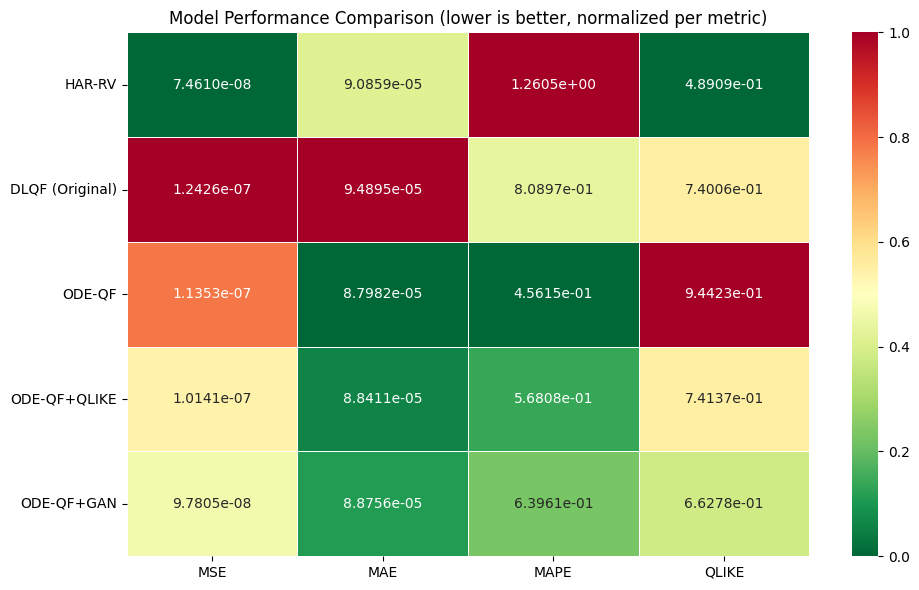

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

models = ['HAR-RV', 'DLQF (Original)', 'ODE-QF', 'ODE-QF+QLIKE', 'ODE-QF+GAN']

data = pd.DataFrame({
    'MSE':   [df_har.loc['MSE'].mean(), df.loc['MSE'].mean(), df_ode.loc['MSE'].mean(), df_ode_qlike.loc['MSE'].mean(), df_ode_dis.loc['MSE'].mean()],
    'MAE':   [df_har.loc['MAE'].mean(), df.loc['MAE'].mean(), df_ode.loc['MAE'].mean(), df_ode_qlike.loc['MAE'].mean(), df_ode_dis.loc['MAE'].mean()],
    'MAPE':  [df_har.loc['MAPE'].mean(), df.loc['MAPE'].mean(), df_ode.loc['MAPE'].mean(), df_ode_qlike.loc['MAPE'].mean(), df_ode_dis.loc['MAPE'].mean()],
    'QLIKE': [df_har.loc['QLIKE'].mean(), df.loc['QLIKE'].mean(), df_ode.loc['QLIKE'].mean(), df_ode_qlike.loc['QLIKE'].mean(), df_ode_dis.loc['QLIKE'].mean()],
}, index=models)

data_norm = (data - data.min()) / (data.max() - data.min())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(data_norm, annot=data.values, fmt='.4e', cmap='RdYlGn_r',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Model Performance Comparison (lower is better, normalized per metric)')
plt.tight_layout()
plt.show()

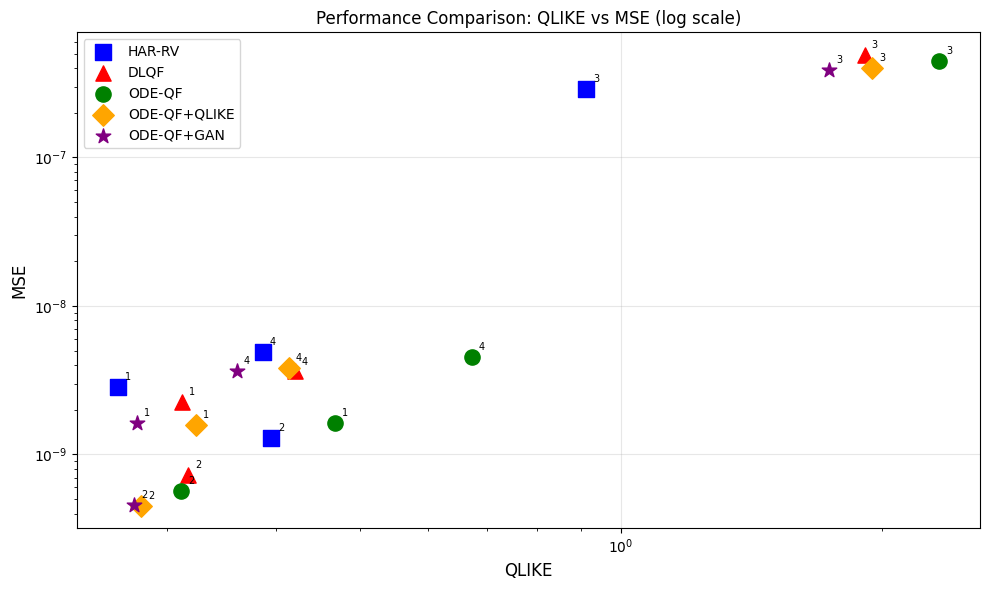

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'HAR-RV': 'blue', 'DLQF': 'red', 'ODE-QF': 'green', 'ODE-QF+QLIKE': 'orange', 'ODE-QF+GAN': 'purple'}
markers = {'HAR-RV': 's', 'DLQF': '^', 'ODE-QF': 'o', 'ODE-QF+QLIKE': 'D', 'ODE-QF+GAN': '*'}

for name, df_model in [('HAR-RV', df_har), ('DLQF', df), ('ODE-QF', df_ode), ('ODE-QF+QLIKE', df_ode_qlike), ('ODE-QF+GAN', df_ode_dis)]:
    for period in df_model.columns:
        qlike_val = df_model.loc['QLIKE', period]
        mse_val = df_model.loc['MSE', period]
        if not np.isnan(qlike_val):
            ax.scatter(qlike_val, mse_val,
                      c=colors[name], marker=markers[name], s=120,
                      label=name if period == 1 else '')
            ax.annotate(str(period), (qlike_val, mse_val),
            textcoords="offset points", xytext=(5, 5), fontsize=7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('QLIKE', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Performance Comparison: QLIKE vs MSE (log scale)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [82]:
(((df_ode - df) / df) * 100)

,1,2,3,4
L2,-18.127594,-20.784296,-19.608507,-1.426400
MSE,-27.568241,-22.510260,-8.781183,25.959328
MAE,-22.983826,-22.963657,-5.911649,1.228861
MAPE,-44.952785,-45.852192,-35.761223,-46.773884
QLIKE,49.827286,-2.004859,21.762068,59.802734


In [83]:
(((df_ode_qlike - df) / df) * 100)

,1,2,3,4
L2,-14.681046,-11.039960,-17.865046,-2.067475
MSE,-30.031755,-37.875134,-18.478954,5.307626
MAE,-15.315620,-19.813576,-5.821390,-2.227387
MAPE,-31.240883,-29.891634,-23.015244,-34.377071
QLIKE,3.599215,-11.755855,2.019007,-1.719597


In [84]:
(((df_ode_qlike - df_ode) / df_ode) * 100)

,1,2,3,4
L2,4.209656,12.301016,2.168715,-0.650351
MSE,-3.401150,-19.828266,-10.631328,-16.395531
MAE,9.956614,4.089088,0.095930,-3.414292
MAPE,24.909346,29.475910,19.841564,23.290848
QLIKE,-30.854240,-9.950490,-16.214460,-38.498924


In [85]:
(((df_ode_dis - df_ode_qlike) / df_ode_qlike) * 100)

,1,2,3,4
L2,-0.271110,0.386064,-1.005527,-1.586163
MSE,2.735976,0.972766,-3.585618,-3.825679
MAE,2.334009,6.857347,-0.132757,0.541637
MAPE,11.189243,19.968006,7.728097,9.658375
QLIKE,-14.456600,-1.791443,-10.759012,-12.805563


In [86]:
(((df_ode_dis - df) / df) * 100)

,1,2,3,4
L2,-14.912355,-10.696517,-18.690935,-3.620845
MSE,-28.117439,-37.270802,-21.401987,1.278895
MAE,-13.339080,-14.314914,-5.946419,-1.697815
MAPE,-23.547258,-15.892391,-17.065788,-28.038961
QLIKE,-11.377709,-13.336699,-8.957231,-14.304956
